# Customer Churn Prediction
# Goal: Predict which telecom customers are likely to leave
# Dataset: Telco Customer Churn (7043 rows, 21 columns)

_______________________________________________
## 1. IMPORTS
 _______________________________________________

In [54]:
# Importing libraries for data manipulation, modeling and evaluation

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

_______________________________________
## 2. Load Data
_______________________________________

In [55]:
# Loading the Telco Customer Churn dataset
df = pd.read_csv("./data/telco_customer_churn.csv")

_______
## 3. EXPLORATORY DATA ANALYSIS (EDA)
_______

### ---- 3.1 Basic Overview ----

In [56]:
# First look at the data — checking structure and sample rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [57]:
# Checking column names, data types and non-null counts
# Note: TotalCharges appears as object but should be numeric — we fix this in preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [58]:
# Statistical summary of numerical columns
# Note: MonthlyCharges ranges from 18 to 118 — large range, standardization needed later
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [59]:
df.shape

(7043, 21)

### ---- 3.2 Data Quality Checks ----

In [60]:
# Checking for duplicate rows — duplicates can cause the model to learn the same pattern twice
df.duplicated().sum()

np.int64(0)

In [61]:
# Checking null values before any changes — expecting 0 here
# Real nulls are hiding as empty strings in TotalCharges, caught after type conversion
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### ---- 3.3 Observations ----

In [62]:
# Checking distribution of all columns to understand our customer base
column_names  = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Churn']

for col in column_names:
    print(df[col].value_counts())
    print('============================')

gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: c

### ---- 3.4 Target Variable Analysis ----
- Understanding churn distribution — how many customers left vs stayed
- This matters because imbalanced data can make our model biased toward the majority class


In [63]:
# Churn Value Counts
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

- Dataset is imbalanced — we will use ROC AUC instead of accuracy to evaluate models


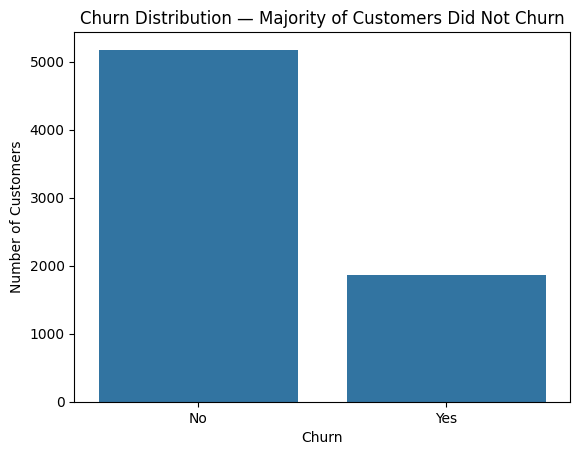

In [64]:
sns.countplot(x = df['Churn'])
plt.title('Churn Distribution — Majority of Customers Did Not Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

- Insight: Only 26.5% of customers churned
- This imbalance means accuracy alone is misleading as an evaluation metric


### ---- 3.5 Univariate Analysis ----

- Looking at individual columns in isolation to understand their distributions


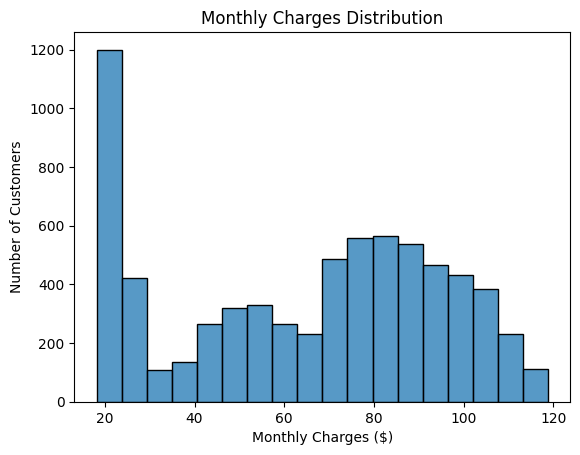

In [65]:
# Distribution of MonthlyCharges — understanding the range of what customers pay
sns.histplot(x = df['MonthlyCharges'])
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.show()

- Charges are spread across 18 to 118 with two peaks
- There are two customer segments - basic and premium service users

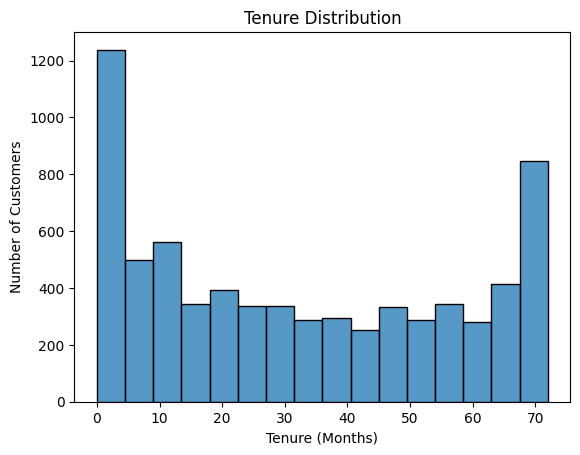

In [66]:
# Distribution of tenure — how long customers have been with the company
sns.histplot(x='tenure', data=df)
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

- Many customers are either very new (tenure 0-5) or very loyal (tenure 60-72)
- Very few in the middle — suggests customers either leave early or commit long term

### ---- 3.6 Bivariate Analysis ----

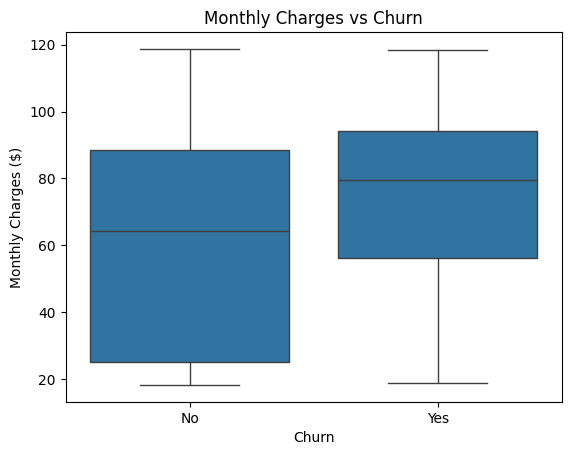

In [67]:
# Question: Do customers with higher monthly charges churn more?
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

In [68]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

- Churners pay median of ~80 vs ~64 for non churners
- Higher charges are clearly linked to higher churn risk


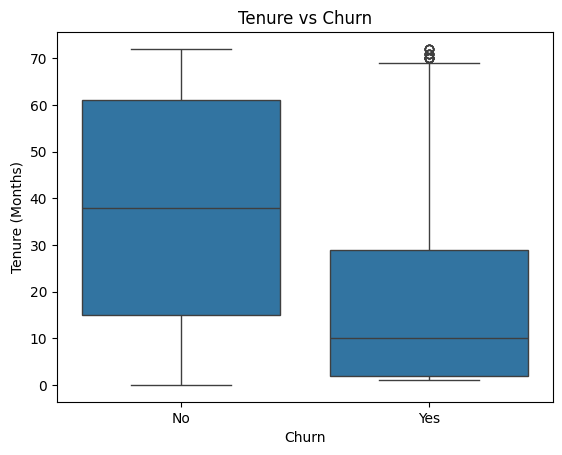

In [69]:
# Question: Do long term customers churn less?
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

- Churners have median tenure of 10 months vs 38 for non churners
- New customers are the highest churn risk — they are still evaluating the service



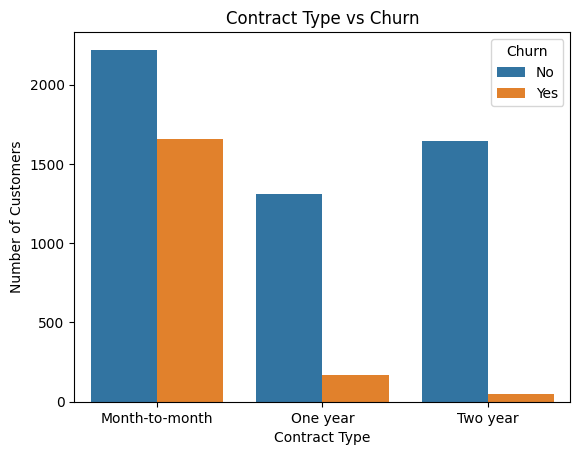

In [70]:
# Question: Does contract type protect against churn?
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

In [71]:
df.groupby('Contract')['Churn'].value_counts(normalize = True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

- Month-to-month 42% churn | One year 11% | Two year only 2%
- Recommendation: Offer incentives to move customers from monthly to annual contracts


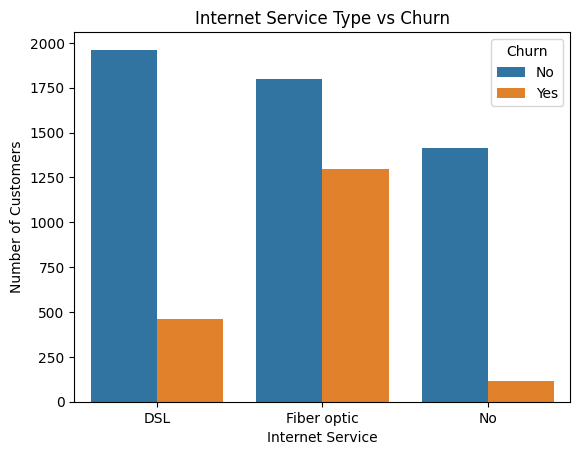

In [72]:
# Which internet service type has the highest churn?
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Internet Service Type vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

In [73]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True)

InternetService  Churn
DSL              No       0.810409
                 Yes      0.189591
Fiber optic      No       0.581072
                 Yes      0.418928
No               No       0.925950
                 Yes      0.074050
Name: proportion, dtype: float64

- Fiber optic customers churn at 41% despite paying the most
- Suggests fiber optic service quality may not meet customer expectations


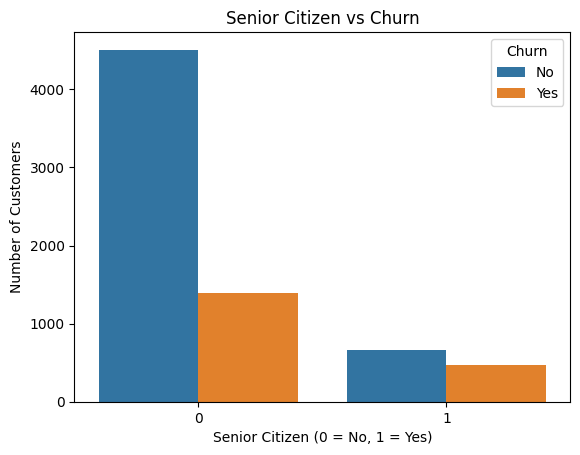

In [74]:
# Do senior citizens churn more than younger customers?
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Senior Citizen vs Churn')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

In [75]:
df['SeniorCitizen'].value_counts(normalize=True)

SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64

In [76]:
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True)

SeniorCitizen  Churn
0              No       0.763938
               Yes      0.236062
1              No       0.583187
               Yes      0.416813
Name: proportion, dtype: float64

- Senior citizens are only 16% of customers but churn at 41%
- Price sensitivity may be a factor — senior citizens on fixed incomes


### ---- 3.7 Correlation Analysis ----
- Checking relationships between numerical columns
- High correlation between two features means they carry similar information (multicollinearity)

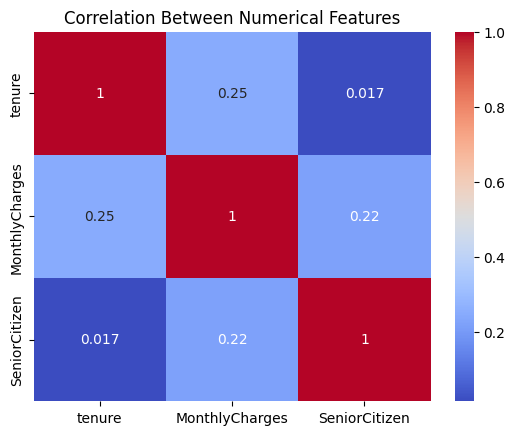

In [77]:
numerical_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Numerical Features')
plt.show()

- No strong correlations found (all below 0.3)
- No multicollinearity concern among numerical features — all three can stay


___
## 4. Data Preprocessing
___

### ---- 4.1 Fix Data Types ----
- TotalCharges is stored as object due to empty strings in some rows
- Converting to numeric — empty strings become NaN so we can handle them properly


In [78]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

### ---- 4.2 Handle Missing Values ----


- Checking nulls after type conversion — now the 11 hidden nulls are visible

In [79]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [80]:
# Investigating the null rows — confirming they all have tenure of 0 (new customers)
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [81]:
# Filling null TotalCharges with MonthlyCharges
# Reason: these customers just joined (tenure=0), their first bill equals their monthly charge
# pandas fills by matching row index so each customer gets their own MonthlyCharges value
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

In [82]:
# Confirming no nulls remain
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### ---- 4.3 Drop Unnecessary Columns ----


In [83]:
# TotalCharges ≈ tenure × MonthlyCharges — redundant information (multicollinearity)
df.drop('TotalCharges', axis= 1, inplace = True)

In [84]:
# Dropping customerID — it is just a unique identifier, teaches the model nothing
df.drop("customerID", axis = 1, inplace = True)

In [85]:
# Confirming final shape after dropping
df.shape

(7043, 19)

### ---- 4.4 Encode Categorical Columns ----

- ML models only understand numbers — all text must be converted


- Label encoding: gender, partner, dependents, paperless billing, churn
- One hot encoding: MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod

In [86]:
# Separating features and target before encoding
X = df.drop('Churn', axis = 1)
y = df['Churn']

In [87]:
# Label encoding binary columns — Yes/No becomes 1/0
# Using label encoding because these columns have only two values (no ranking issue)
binary_col_x = ['gender', 'Partner', 'Dependents', 'PaperlessBilling', 'PhoneService']
for col in binary_col_x:     
    le = LabelEncoder() 
    X[col] = le.fit_transform(X[col])

# Encoding target variable separately — Churn Yes/No becomes 1/0
le = LabelEncoder()
y = le.fit_transform(y)

In [88]:
# One hot encoding multi-category columns
# Using get_dummies because these columns have 3+ unranked values
# drop_first=True removes one column per feature to avoid redundancy (dummy variable trap)
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

X = pd.get_dummies(X, columns=multi_cols, drop_first=True)

### ---- 4.5 Train Test Split ----

- 80% training data — model learns from this
- 20% test data — model is evaluated on unseen data
- stratify=y ensures same churn ratio in both splits — important for imbalanced data
- random_state=42 ensures same split every time we run the code

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 42, stratify=y)

### ---- 4.6 Feature Scaling ----

- StandardScaler makes all numerical columns weigh the same
- Without scaling, tenure (0-72) would dominate over SeniorCitizen (0-1)
- Fit only on training data — fitting on test data would cause data leakage

In [92]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

_______
## 5. MODEL TRAINING AND EVALUATION
_______

### ---- 5.1 Logistic Regression ----

In [93]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [94]:
accuracy = accuracy_score(y_test, y_pred_lr)
print(accuracy)

0.7977288857345636


In [95]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[918 117]
 [168 206]]


In [96]:
cr = classification_report(y_test, y_pred_lr)
print(cr)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



- Recall for class 1 (churners) is most important metric here
- We want to catch as many real churners as possible before they leave

In [97]:
roc_auc = roc_auc_score(y_test, y_prob_lr)
print(roc_auc)

0.8388333462502261


- ROC AUC — measures how well model separates churners from non churners
- 0.5 = random guessing | 1.0 = perfect separation

### ---- 5.2 Random Forest ----

In [98]:
rfc_model = RandomForestClassifier(random_state=42)
rfc_model.fit(X_train, y_train)
y_pred_rf = rfc_model.predict(X_test)
y_prob_rf = rfc_model.predict_proba(X_test)[:, 1]

In [99]:
accuracy = accuracy_score(y_test, y_pred_rf)
print(accuracy)

0.7828246983676366


In [100]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[922 113]
 [193 181]]


In [101]:
cr = classification_report(y_test, y_pred_rf)
print(cr)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [102]:
roc_auc = roc_auc_score(y_test, y_prob_rf)
print(roc_auc)

0.8158684026970472


### ---- 5.3 Model Comparison ----

Comparing both models to choose the best one for deployment

In [103]:
print("=" * 40)
print("MODEL COMPARISON")
print("=" * 40)
print(f"{'Metric':<20} {'Logistic Regression':<25} {'Random Forest'}")
print(f"{'Accuracy':<20} {accuracy_score(y_test, y_pred_lr):<25.4f} {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"{'ROC AUC':<20} {roc_auc_score(y_test, y_prob_lr):<25.4f} {roc_auc_score(y_test, y_prob_rf):.4f}")

MODEL COMPARISON
Metric               Logistic Regression       Random Forest
Accuracy             0.7977                    0.7828
ROC AUC              0.8388                    0.8159


- Conclusion: Logistic Regression wins on all metrics
- Simpler model generalised better — Random Forest likely overfit the training data
- For this business problem, recall matters most — LR catches more real churners

### ---- 5.4 Feature Importance ----


- Which columns did Random Forest find most useful for predicting churn?
- Higher importance = column was used more often to make correct splits across 100 trees

In [104]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rfc_model.feature_importances_
}).sort_values(by = 'Importance', ascending=False).head(15)

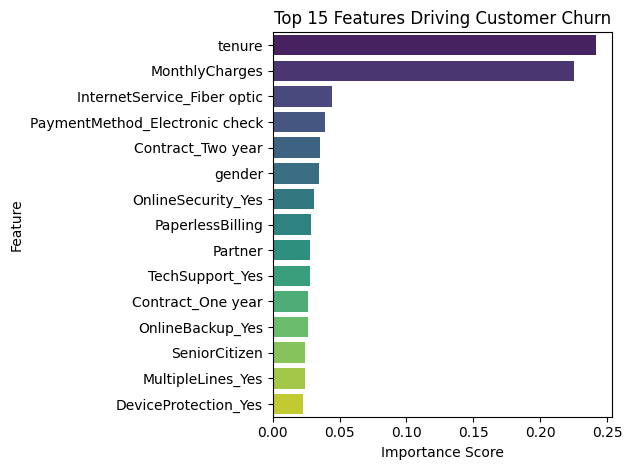

In [105]:
sns.barplot(x='Importance', y='Feature',
            data=feature_importance, palette='viridis')
plt.title('Top 15 Features Driving Customer Churn')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

- Insight: Tenure and MonthlyCharges are top predictors
- Electronic check payment method also significant — manual payers think about bills more

_______
## 6. SAVE MODELS
_______

- Saving trained models and scaler so Streamlit can load them without retraining
- Loading a saved model is instant — retraining every time would make app unusably sl- 

In [106]:
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(rfc_model, 'rfc_model.pkl')
joblib.dump( scaler, 'scaler.pkl')
joblib.dump( X.columns.to_list(), 'feature_names.pkl')

['feature_names.pkl']

In [107]:
import os
os.listdir('.')

['app.py',
 'churn_model.ipynb',
 'data',
 'feature_names.pkl',
 'lr_model.pkl',
 'requirements.txt',
 'rfc_model.pkl',
 'scaler.pkl']